# Plot proportions of cell types by mortality and pathogens

In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import itertools

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.stats.multitest

import common_data
import common_plots

In [3]:
%config InlineBackend.figure_format = "retina"

In [4]:
common_plots.setup_plotting()

In [5]:
labels = pd.read_csv(common_data.CLINICAL_LABELS, index_col=0)
flow = pd.read_csv(common_data.FLOW, index_col=0)
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

In [6]:
flow = flow.drop_duplicates(subset='bal_barcode')

In [7]:
flow_cell_types = flow.columns[4:11]

In [8]:
flow_cell_types

Index(['CD4 T cells percent', 'CD8 T cells percent', 'Treg cells percent',
       'Neutrophils percent', 'CD206high macs percent',
       'CD206low macs percent', 'Monocytes percent'],
      dtype='object')

In [ ]:
# Create a copy of the flow dataframe with the cell type columns
flow_norm = flow[['bal_barcode'] + list(flow_cell_types)].copy()

flow_norm[flow_cell_types] = np.log1p(flow_norm[flow_cell_types])
# flow_norm[flow_cell_types] = flow_norm[flow_cell_types] + 1

In [ ]:
ds = flow_norm.merge(labels, left_on='bal_barcode', right_on='bal_barcode', how='left', suffixes=('_flow', ''))

In [79]:
ds.shape

(792, 86)

In [80]:
ds = ds.merge(ehr[['bal_barcode', 'Gender']], left_on='bal_barcode', right_on='bal_barcode', how='left')

In [81]:
ds.shape

(792, 87)

In [82]:
ds['broad_perturbation_groups'] = ds['perturbation_groups_2'].replace({
    'Gram-*': 'Bacterial',
    'NPC': 'discard',
    'Gram+': 'Bacterial',
    'Late SARS-CoV-2; Gram+': 'Mixed',
    'Gram-*; Gram+': 'Bacterial',
    'Pseudomonas aeruginosa': 'Bacterial',
    'Early SARS-CoV-2; Gram+': 'Mixed',
    'Pseudomonas aeruginosa; SARS-CoV-2': 'Mixed',
})

In [83]:
ds.broad_perturbation_groups = pd.Categorical(ds.broad_perturbation_groups, categories=[
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Bacterial',
    'Mixed',
    'discard'
])

In [ ]:
COVARIATES = [
    'Binary_outcome', 'broad_perturbation_groups'
]

NA_VALUES = {
    'broad_perturbation_groups': 'discard',
}

cell_columns_pretty_names = {
    'CD4 T cells percent': 'CD4$^{+}$ T cells',
    'CD8 T cells percent': 'CD8$^{+}$ T cells',
    'Treg cells percent': 'T$_{\\text{reg}}$ cells',
    'CD206high macs percent': 'CD206$^{\\text{hi}}$ macrophages',
    'CD206low macs percent': 'CD206$^{\\text{lo}}$ macrophages',
    'Monocytes percent': 'Monocytes',
    'Neutrophils percent': 'Neutrophils'
}

In [84]:
ds = ds.melt(
    id_vars=['bal_barcode'] + COVARIATES,
    value_vars=flow_cell_types,
    var_name='cell_type',
    value_name='value'
)

/tmp/ipykernel_2714643/3211338648.py:24: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipykernel_2714643/3211338648.py:24: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipykernel_2714643/3211338648.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


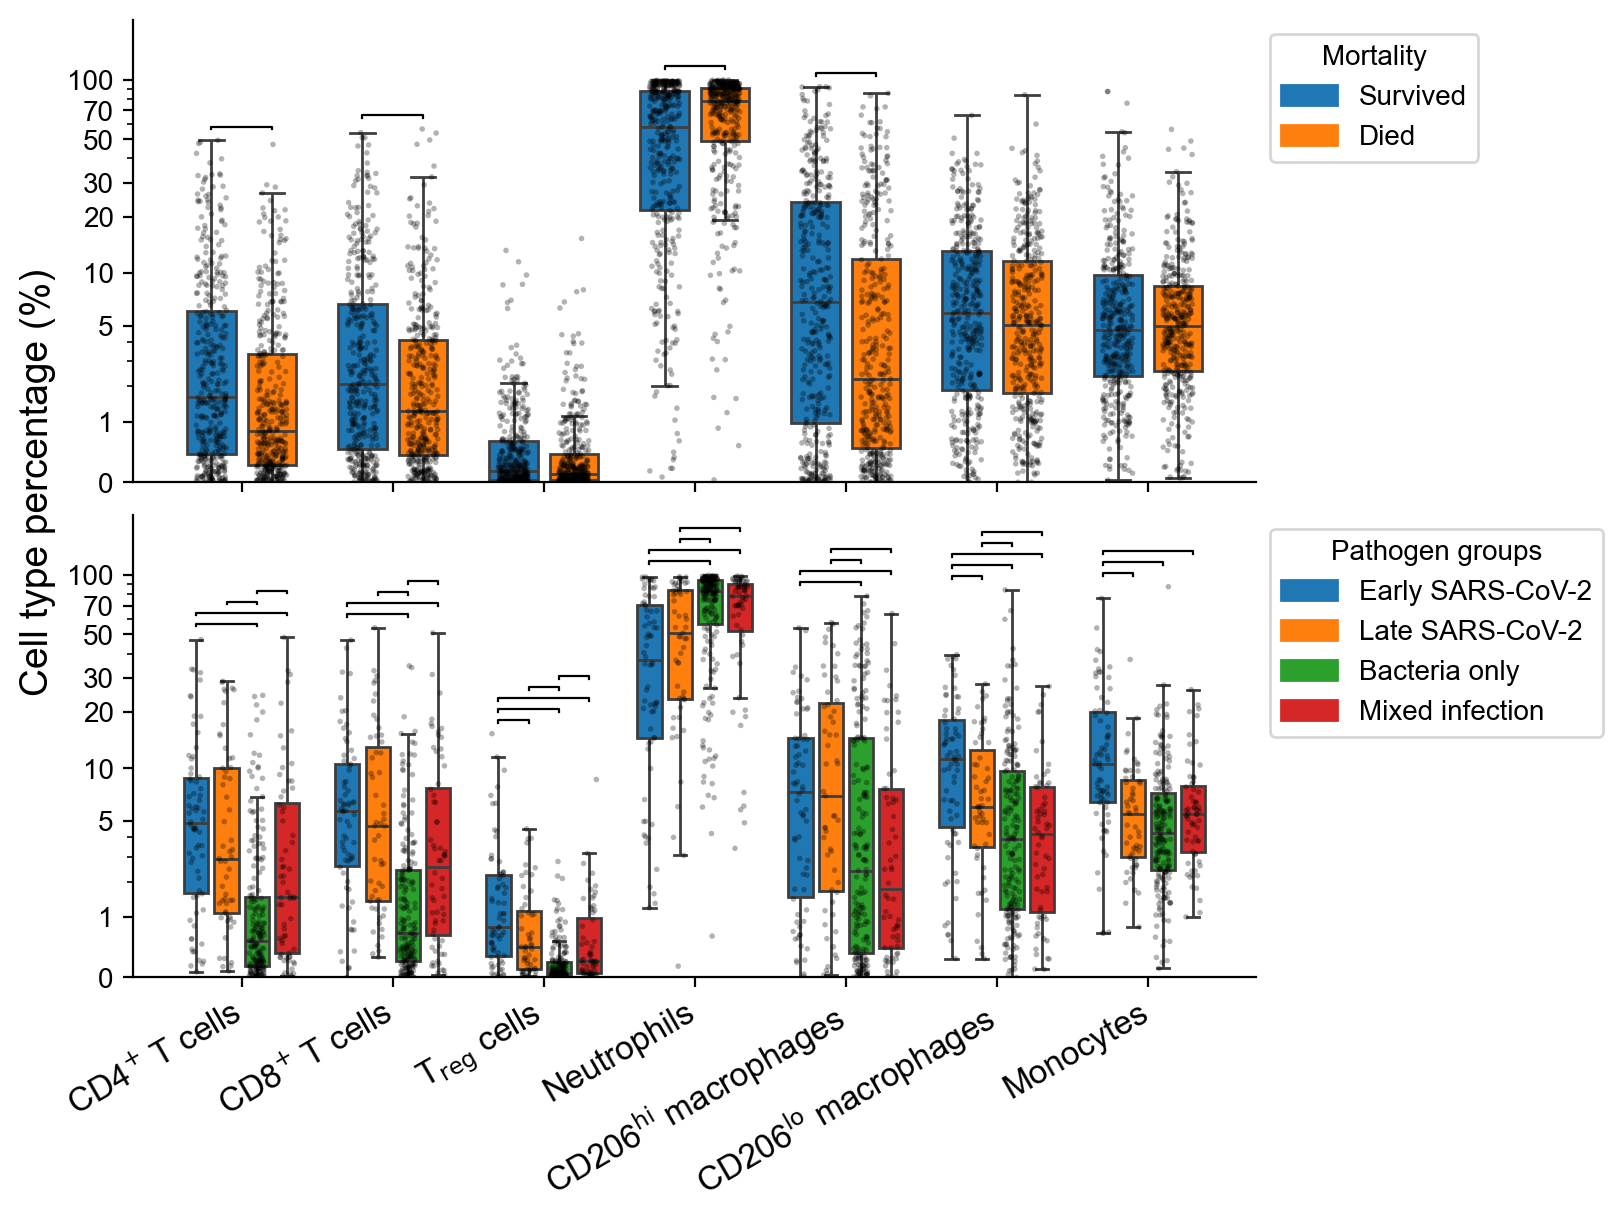

In [ ]:
YTICKS_MAJOR = [0, 1, 5, 10, 20, 30, 50, 70, 100]
YTICKS_MINOR = [2, 3, 4, 40, 60, 80, 90]

fig, axes = plt.subplots(figsize=(8, 6), nrows=2, ncols=1, sharex=True, constrained_layout=True)
for i, cov in enumerate(['Binary_outcome', 'broad_perturbation_groups']):
    ax = axes[i]
    plot_df = ds.copy()
    if cov in NA_VALUES:
        plot_df = plot_df[plot_df[cov] != NA_VALUES[cov]]
        if pd.api.types.is_categorical_dtype(plot_df[cov]):
            plot_df[cov] = plot_df[cov].cat.remove_unused_categories()

    # Create boxplot with hue
    sns.boxplot(
        data=plot_df,
        x='cell_type',
        y='value',
        hue=cov,
        ax=ax,
        showfliers=False,
        saturation=1,
        gap=0.2,
    )
    sns.stripplot(
        data=plot_df,
        x='cell_type',
        y='value',
        ax=ax,
        size=2,
        hue=cov,
        dodge=True,
        palette=['k'],
        legend=False,
        alpha=0.3,
        jitter=0.2
    )
    ax.set_ylim(0, np.log1p(200))
    ax.set_yticks(np.log1p(YTICKS_MAJOR), labels=YTICKS_MAJOR)
    ax.set_yticks(np.log1p(YTICKS_MINOR), minor=True)
    h, l = ax.get_legend_handles_labels()
    ax.legend(
        h,
        l,
        title=cov,
        bbox_to_anchor=(1, 1),
        loc='upper left',
        # fontsize=6,
        # title_fontsize=6,
    )
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('')
    if i == 0:
        ax.set_ylabel('Cell type percentage (%)', fontsize=14, y=0, ha='center')
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(1, 1),
            title='Mortality',
            handles=[
                mpl.patches.Patch(color='C0', label='Survived'),
                mpl.patches.Patch(color='C1', label='Died'),
            ]
        )
    if i == 1:
        ax.set_xlabel('')
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(1, 1),
            title='Pathogen groups',
            handles=[
                mpl.patches.Patch(color='C0', label='Early SARS-CoV-2'),
                mpl.patches.Patch(color='C1', label='Late SARS-CoV-2'),
                mpl.patches.Patch(color='C2', label='Bacteria only'),
                mpl.patches.Patch(color='C3', label='Mixed infection'),
            ]
        )
        ax.set_xticklabels(
            [cell_columns_pretty_names[n.get_text()] for n in ax.get_xticklabels()],
            rotation=30,
            ha='right',
            fontsize=12,
        )
        trans = mpl.transforms.Affine2D().translate(6, 0)
        for n in ax.get_xticklabels():
            n.set_transform(n.get_transform() + trans)

    # Get hue labels and map to their positions
    hue_categories = sorted(plot_df[cov].unique())
    if isinstance(plot_df[cov].dtype, pd.CategoricalDtype):
        hue_categories = list(plot_df[cov].cat.categories)
    stats_results = []
    # Get statistical tests
    for ct in plot_df.cell_type.unique():
        for d1, d2 in itertools.combinations(hue_categories, 2):
            days1 = plot_df.loc[plot_df[cov].eq(d1) & plot_df.cell_type.eq(ct), 'value'].dropna()
            days2 = plot_df.loc[plot_df[cov].eq(d2) & plot_df.cell_type.eq(ct), 'value'].dropna()
            if days1.size == 0 or days2.size == 0:
                continue
            pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
            stats_results.append([ct, d1, d2, days1.size, days2.size, pval])

    stats_results = pd.DataFrame(
        stats_results,
        columns=["cell_type", "group1", "group2", "group1_size", "group2_size", "pval"]
    )
    stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
    stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

    if len(stats_results_sign) == 0:
        continue

    # Get the number of hue categories for proper positioning
    n_hue_cats = len(plot_df[cov].unique())
    width = 0.8  # default width of seaborn boxplot

    # Get cell type labels and their positions
    cell_types = plot_df.cell_type.unique()
    cell_type_positions = {ct: i for i, ct in enumerate(cell_types)}

    hue_offsets = np.linspace(0, width - width / n_hue_cats, n_hue_cats) + width / (2 * n_hue_cats) - width / 2

    start_height = plot_df.groupby('cell_type')['value'].max().to_dict()
    incrementer = 5 # px
    q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
    y_offset = q[1][1] - q[0][1]
    gap = y_offset / 4

    # Add annotations for significant comparisons
    for _, r in stats_results_sign.iterrows():
        cell_type = r.cell_type
        base_x = cell_type_positions[cell_type]
        base_y = start_height[cell_type]

        # Get the x positions for each hue level within this cell type
        hue1_idx = hue_categories.index(r.group1)
        hue2_idx = hue_categories.index(r.group2)
        x1 = base_x + hue_offsets[hue1_idx]
        x2 = base_x + hue_offsets[hue2_idx]

        # Format p-value
        p_text = f'$p={r.padj:.3f}$'

        # Add bracket and annotation
        y = base_y + y_offset
        ax.plot([x1, x1, x2, x2], [y, y+gap, y+gap, y], lw=0.8, c='k')
        # ax.text((x1+x2)/2, y+gap, p_text, ha='center', va='bottom', fontsize=6)

        # Increment height for next annotation if needed
        start_height[cell_type] += y_offset
fig.savefig('10_flow_norm.pdf')